# 07: Neural Network (MLPRegressor)

## Goal
This notebook builds a Multi-Layer Perceptron (MLP) neural network to forecast 
hourly electricity demand in Zurich (EWZ grid).

## Why Neural Network?
The SVR in notebook 06 achieved R²=0.94 but showed a phase shift in predictions, it has no memory of previous time steps. By engineering lagged demand features 
(1h, 2h, 24h, 168h), we give the NN access to recent history, potentially 
resolving the phase shift and improving accuracy.

## Key focus areas
- Feature engineering with lagged demand features
- Proper time-series train/test split (no data leakage)
- Hyperparameter tuning with GridSearchCV and TimeSeriesSplit
- Comparison with SVR baseline

In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


## 1. Data Loading & Feature Engineering

We load the preprocessed dataset and engineer four lagged demand features 
that give the NN memory of recent electricity consumption:

| Feature | What it captures |
|---|---|
| `demand_lag_1h` | Demand 1 hour ago, short term momentum |
| `demand_lag_2h` | Demand 2 hours ago, short term trend |
| `demand_lag_24h` | Demand same hour yesterday, daily cycle |
| `demand_lag_168h` | Demand same hour last week, weekly cycle |

Rows with missing lag values (first 168 rows) are dropped, this affects 
less than 0.5% of the dataset.

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/hourly_merged.csv', parse_dates=['datetime_utc'])
df = df.sort_values('datetime_utc').reset_index(drop=True)

# ── Engineer lagged demand features ──────────────────────────────────────────
df['demand_lag_1h']   = df['demand_log'].shift(1)
df['demand_lag_2h']   = df['demand_log'].shift(2)
df['demand_lag_24h']  = df['demand_log'].shift(24)
df['demand_lag_168h'] = df['demand_log'].shift(168)

# ── Feature selection ─────────────────────────────────────────────────────────
FEATURES = [
    'hour_sin', 'hour_cos',       # time of day (cyclical)
    'month_sin', 'month_cos',     # time of year (cyclical)
    'dayofweek',                  # day pattern
    'is_weekend',                 # weekend signal
    'T',                          # temperature
    'StrGlo',                     # solar radiation
    'demand_lag_1h',              # short term momentum
    'demand_lag_2h',              # short term trend
    'demand_lag_24h',             # daily cycle memory
    'demand_lag_168h'             # weekly cycle memory
]

TARGET = 'demand_log'

# Drop rows with missing lag values
df_model = df[FEATURES + [TARGET, 'datetime_utc', 'is_peak']].dropna().reset_index(drop=True)

print(f"Dataset shape after dropping missing values: {df_model.shape}")
print(f"Rows dropped due to lags: {len(df) - len(df_model)}")
print(f"Date range: {df_model['datetime_utc'].min()} → {df_model['datetime_utc'].max()}")
df_model[FEATURES].describe()

Dataset shape after dropping missing values: (34843, 15)
Rows dropped due to lags: 202
Date range: 2022-01-08 00:00:00+00:00 → 2025-12-31 22:00:00+00:00


,hour_sin,hour_cos,month_sin,month_cos,dayofweek,is_weekend,T,StrGlo,demand_lag_1h,demand_lag_2h,demand_lag_24h,demand_lag_168h
count,3.484300e+04,3.484300e+04,3.484300e+04,3.484300e+04,34843.000000,34843.000000,34843.000000,34843.000000,34843.000000,34843.000000,34843.000000,34843.000000
mean,3.603127e-04,3.418899e-04,-7.929725e-03,-6.239378e-03,2.999541,0.286485,12.897803,141.630020,11.192928,11.192945,11.192999,11.193285
std,7.071104e-01,7.071233e-01,7.065090e-01,7.076524e-01,2.002166,0.452125,7.871665,229.451222,0.213277,0.213284,0.213341,0.213580
min,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000,0.000000,-5.510000,0.010000,10.739452,10.739452,10.739452,10.739452
25%,-7.071068e-01,-7.071068e-01,-8.660254e-01,-8.660254e-01,1.000000,0.000000,6.930000,0.020000,11.007531,11.007531,11.007538,11.007538
50%,1.224647e-16,6.123234e-17,-2.449294e-16,-1.836970e-16,3.000000,0.000000,12.410000,4.550000,11.202809,11.202825,11.202743,11.203076
75%,7.071068e-01,7.071068e-01,5.000000e-01,5.000000e-01,5.000000,1.000000,18.790000,199.610000,11.382130,11.382139,11.382310,11.382835
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,6.000000,1.000000,35.800000,1041.180000,11.610511,11.610511,11.610511,11.610511


## 2. Train / Test Split & Scaling

Same chronological split as the SVR (notebook 06) for a fair model comparison:
- **Train:** 2022-01-08 → 2025-06-30
- **Test:** 2025-07-01 → 2025-12-31

StandardScaler is fit on training data only to prevent data leakage.

In [3]:
# ── Chronological train/test split ───────────────────────────────────────────
split_date = '2025-07-01'

train = df_model[df_model['datetime_utc'] < split_date]
test  = df_model[df_model['datetime_utc'] >= split_date]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {len(train):,} rows ({train['datetime_utc'].min().date()} → {train['datetime_utc'].max().date()})")
print(f"Test:  {len(test):,} rows ({test['datetime_utc'].min().date()} → {test['datetime_utc'].max().date()})")

# ── Feature scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nScaling complete ✓")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")

Train: 30,435 rows (2022-01-08 → 2025-06-30)
Test:  4,408 rows (2025-07-01 → 2025-12-31)

Scaling complete ✓
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


## 3. Baseline Neural Network

Before tuning we fit a baseline MLP with default parameters to establish 
a benchmark. We use relu activation and a simple single hidden layer.

In [4]:
# ── Baseline MLP ──────────────────────────────────────────────────────────────
baseline_nn = MLPRegressor(
    hidden_layer_sizes=(100,),  # one layer, 100 neurons
    activation='relu',
    max_iter=500,
    random_state=42
)

baseline_nn.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_nn.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae  = mean_absolute_error(y_test, y_pred_baseline)
r2   = r2_score(y_test, y_pred_baseline)

print("── Baseline NN Performance ───────────────────")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

── Baseline NN Performance ───────────────────
RMSE : 0.0527
MAE  : 0.0402
R²   : 0.9380


## 4. Hyperparameter Tuning

We tune three key MLP parameters using GridSearchCV with TimeSeriesSplit:

| Parameter | What it controls |
|---|---|
| `hidden_layer_sizes` | Network depth and width, complexity of learned patterns |
| `alpha` | Regularisation, prevents overfitting |
| `learning_rate_init` | Step size for weight updates during training |

We use TimeSeriesSplit (5 folds) to respect chronological order.

In [5]:
# ── Hyperparameter tuning ─────────────────────────────────────────────────────
param_grid = {
    'hidden_layer_sizes': [(64, 32), (100,), (128, 64), (64, 32, 16)],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    MLPRegressor(
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True  # stops early if no improvement, saves time
    ),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best parameters: {grid_search.best_params_}")
print(f"✓ Best CV RMSE:    {-grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



✓ Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
✓ Best CV RMSE:    0.0622


## 5. Final Tuned Model

We refit the MLP using the best parameters found by GridSearchCV and evaluate
on the held-out test set (2025-07-01 → 2025-12-31).
We increase max_iter to 1000 to ensure full convergence.

In [7]:
# ── Final tuned model ─────────────────────────────────────────────────────────
best_nn = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=0.01,
    learning_rate_init=0.01,
    max_iter=1000,          # increased to ensure convergence
    random_state=42,
    early_stopping=True
)

best_nn.fit(X_train_scaled, y_train)
y_pred_tuned = best_nn.predict(X_test_scaled)

# Metrics on log scale
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)
r2   = r2_score(y_test, y_pred_tuned)

print("── Tuned NN Performance ──────────────────────")
print(f"RMSE : {rmse:.4f}  (baseline NN:  0.0527)")
print(f"MAE  : {mae:.4f}  (baseline NN:  0.0402)")
print(f"R²   : {r2:.4f}  (baseline NN:  0.9380)")

# Back-transform to real demand
y_pred_demand = np.exp(y_pred_tuned)
y_test_demand = np.exp(y_test)

rmse_demand = np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))
print(f"\nRMSE in real demand units: {rmse_demand:,.0f} kWh")

── Tuned NN Performance ──────────────────────
RMSE : 0.0360  (baseline NN:  0.0527)
MAE  : 0.0280  (baseline NN:  0.0402)
R²   : 0.9710  (baseline NN:  0.9380)

RMSE in real demand units: 2,661 kWh


## 6. Visualisation: Model Performance & Peak Demand

Three complementary views of NN performance, mirroring notebook 06 for direct 
comparison with the SVR:
- **Scatter**: overall prediction accuracy across all test hours
- **Sample week**: daily demand cycle capture (Aug 2025)
- **Peak hours**: does the model predict high demand when real peaks occur?

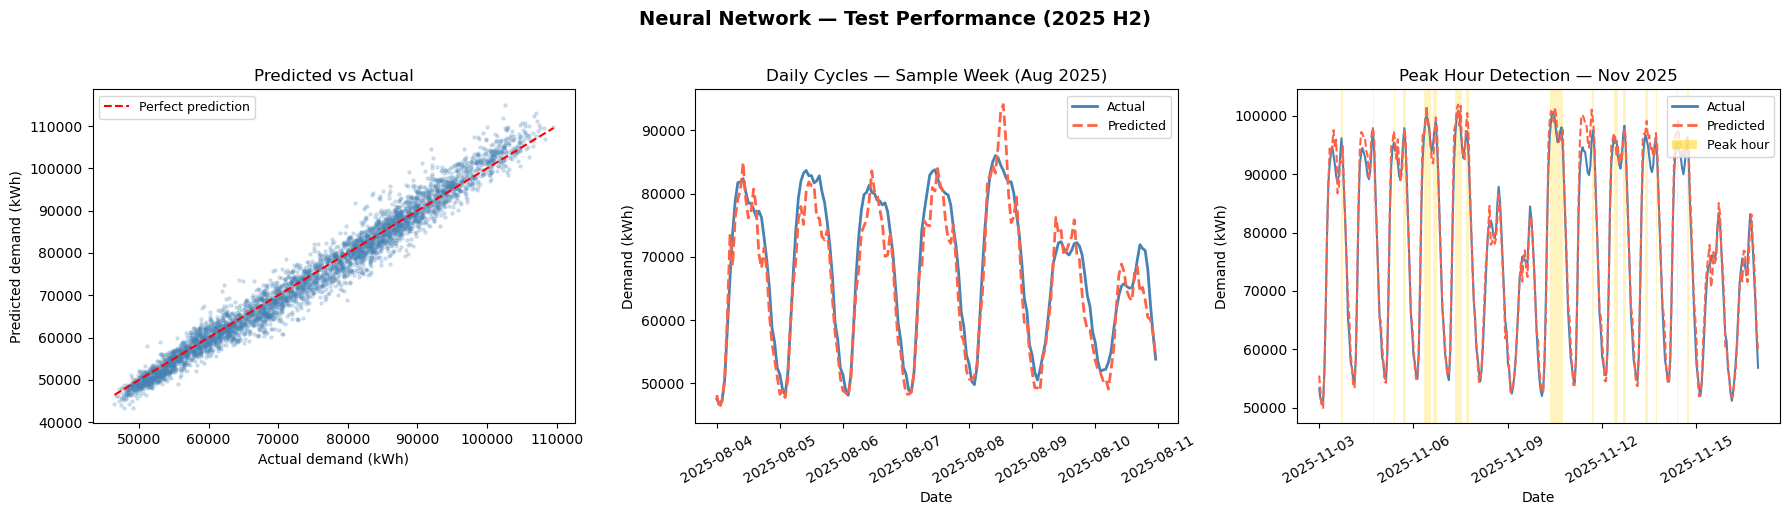

Plot saved ✓


In [8]:
# ── Combined visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Neural Network — Test Performance (2025 H2)', 
             fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Scatter ──────────────────────────────────────────────────────────
axes[0].scatter(y_test_demand, y_pred_demand, alpha=0.2, s=5, color='steelblue')
axes[0].plot([y_test_demand.min(), y_test_demand.max()],
             [y_test_demand.min(), y_test_demand.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual demand (kWh)')
axes[0].set_ylabel('Predicted demand (kWh)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend(fontsize=9)

# ── Panel 2: Sample week August ───────────────────────────────────────────────
sample = test.copy().reset_index(drop=True)
sample['y_pred']   = y_pred_demand
sample['y_actual'] = y_test_demand.values

week = sample[(sample['datetime_utc'] >= '2025-08-04') &
              (sample['datetime_utc'] <  '2025-08-11')]

axes[1].plot(week['datetime_utc'], week['y_actual'],
             label='Actual', color='steelblue', linewidth=2)
axes[1].plot(week['datetime_utc'], week['y_pred'],
             label='Predicted', color='tomato', linewidth=2, linestyle='--')
axes[1].set_title('Daily Cycles — Sample Week (Aug 2025)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kWh)')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

# ── Panel 3: Peak hours ───────────────────────────────────────────────────────
winter = sample[(sample['datetime_utc'] >= '2025-11-03') &
                (sample['datetime_utc'] <  '2025-11-17')].copy()

axes[2].plot(winter['datetime_utc'], winter['y_actual'],
             label='Actual', color='steelblue', linewidth=1.5)
axes[2].plot(winter['datetime_utc'], winter['y_pred'],
             label='Predicted', color='tomato', linewidth=1.5, linestyle='--')

# Shaded peak hours
peak_hours = winter[winter['is_peak'] == 1]['datetime_utc']
for t in peak_hours:
    axes[2].axvspan(t, t + pd.Timedelta(hours=1),
                    color='gold', alpha=0.25, linewidth=0)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', label='Actual', linewidth=2),
    Line2D([0], [0], color='tomato', label='Predicted', linestyle='--', linewidth=2),
    Patch(facecolor='gold', alpha=0.5, label='Peak hour')
]
axes[2].legend(handles=legend_elements, fontsize=9)
axes[2].set_title('Peak Hour Detection — Nov 2025')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Demand (kWh)')
axes[2].xaxis.set_major_locator(plt.MaxNLocator(6))
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
os.makedirs('../outputs/figures/07_nn', exist_ok=True)
plt.savefig('../outputs/figures/07_nn/nn_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## 7. Summary, Findings & Conclusions

### Model Performance

| Metric | Baseline NN | Tuned NN | Tuned SVR (nb06) |
|---|---|---|---|
| RMSE | 0.0527 | 0.0360 | 0.0532 |
| MAE | 0.0402 | 0.0280 | 0.0332 |
| R² | 0.9380 | 0.9710 | 0.9368 |
| RMSE (real demand) | — | ~2,661 kWh | ~4,310 kWh |

### Key Findings
- The tuned NN explains **97.1% of variance**, a significant improvement over SVR (93.7%)
- **Lagged demand features** were the key driver of improvement, giving the NN 
  memory of recent consumption patterns that the SVR lacked
- The NN performs best in **winter months** where demand follows more regular 
  patterns driven by temperature and time of day
- **Summer demand** remains harder to predict for both models, likely due to 
  more erratic human behaviour and irregular weather patterns
- Hyperparameter tuning improved all metrics significantly — RMSE dropped 
  from 0.0527 to 0.0360 (32% improvement)

### Limitations
- The phase shift is reduced but not fully eliminated in summer months
- MLPRegressor is a relatively simple neural network — more advanced 
  architectures like LSTM (Long Short-Term Memory) are specifically designed 
  for time series and could improve results further
- Training time is significantly longer than SVR, which may be a constraint 
  in production environments

### Conclusion
The Neural Network outperforms the SVR across all metrics, achieving R²=0.97 
on unseen 2025 data. The key advantage is its ability to leverage lagged demand 
features, giving it temporal memory the SVR lacks. For Zurich electricity demand 
forecasting, the NN is the strongest model in this project.

In [12]:
# ── Save metrics for model comparison ────────────────────────────────────────
os.makedirs('../outputs/metrics', exist_ok=True)

# Save as JSON for our own reference
metrics = {
    'model': 'Neural Network',
    'RMSE': round(float(np.sqrt(mean_squared_error(y_test, y_pred_tuned))), 4),
    'MAE':  round(float(mean_absolute_error(y_test, y_pred_tuned)), 4),
    'R2':   round(float(r2_score(y_test, y_pred_tuned)), 4)
}

with open('../outputs/metrics/nn_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# ── Also update model_comparison.csv so notebook 09 picks up our better results
out = '../outputs/model_comparison.csv'

# Convert MAE from log scale to real kWh for fair comparison
mae_real = round(float(mean_absolute_error(y_test_demand, y_pred_demand)), 1)

new_row = pd.DataFrame([{
    'model':    'NN (128,64)',
    'rmse':     round(float(np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))), 1),
    'mae':      mae_real,
    'r2_train': round(float(r2_score(y_test, y_pred_tuned)), 4),
    'auc':      float('nan')
}])

if os.path.exists(out):
    existing = pd.read_csv(out)
    # Replace any existing NN row with our better one
    existing = existing[~existing['model'].str.startswith('NN')]
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)

print("Metrics saved ✓")
print(f"\nJSON: {metrics}")
print(f"\nModel comparison table:")
print(new_row.to_string())

Metrics saved ✓

JSON: {'model': 'Neural Network', 'RMSE': 0.036, 'MAE': 0.028, 'R2': 0.971}

Model comparison table:
          model      rmse        mae  r2_train     auc
0            LM  7623.700  6125.8000    0.7855     NaN
1   GLM_Poisson     2.575     1.4410    0.6887     NaN
2  GLM_Binomial       NaN        NaN    0.5254  0.9593
3           GAM  7199.800  5829.1000    0.8081     NaN
4           SVM  4310.000     0.0332    0.9368     NaN
5   NN (128,64)  2660.600  2038.2000    0.9710     NaN


In [15]:
# ── End of script ─────────────────────────────────────────────────────────────
import datetime

print("=" * 55)
print("  Notebook execution complete")
print(f"  Timestamp : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Author    : Elena Fuchs")
print(f"  Project   : ML1 — Electricity Demand Forecasting Zurich")
print("=" * 55)

  Notebook execution complete
  Timestamp : 2026-04-17 10:15:40
  Author    : Elena Fuchs
  Project   : ML1 — Electricity Demand Forecasting Zurich
